In [1]:
import tensorflow as tf

import tensorflow.keras.utils as utils

import tensorflow.keras.applications as applications

import tensorflow_datasets as tfds

tfds.disable_progress_bar()

import warnings; warnings.filterwarnings('ignore')

import os, pathlib

In [ ]:
dataset = "cats_vs_dogs"

split = ["train[:10%]", "train[80%:90%]", "train[90%:]"]

ontrue = True

(train, test, validation) = tfds.load(dataset, split=split, as_supervised=ontrue)

In [3]:
len(train), len(test), len(validation)

(2326, 2326, 2326)

In [4]:
input_shape = (160, 160)

inlabel = lambda i, l : (tf.image.resize(i, input_shape) / 255.0, l)

batch = 128

train = train.map(inlabel).shuffle(len(train)).batch(batch).cache()

test = test.map(inlabel).batch(batch)

validation = validation.map(inlabel).batch(batch)

In [ ]:
from tensorflow.keras.applications import MobileNet

import tensorflow.keras.layers as layers

inputs = layers.Input((160, 160, 3))

intnet = MobileNet(input_tensor=inputs, weights='imagenet', include_top=False)

intnet.trainable = False

x = layers.GlobalAveragePooling2D()(intnet.output)

output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, output)

In [6]:
model.input

<KerasTensor shape=(None, 160, 160, 3), dtype=float32, sparse=None, name=keras_tensor>

In [7]:
model.output

<KerasTensor shape=(None, 1), dtype=float32, sparse=False, name=keras_tensor_87>

In [ ]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(train, validation_data=validation, epochs=7)

In [9]:
model.evaluate(train, verbose=False)

[0.07490244507789612, 0.9759243130683899]

In [10]:
model.evaluate(test, verbose=False)

[0.09370782971382141, 0.9638864994049072]

In [11]:
model.evaluate(validation, verbose=False)

[0.08118601143360138, 0.969475507736206]

In [12]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

class Helplot:
  def __init__(self, history):
    self.history = history
    self.accuracy = history.history['accuracy']
    self.val_accuracy = history.history['val_accuracy']
    self.loop = [*range(1, len(self.accuracy) + 1)]
    self.loss = history.history['loss']
    self.val_loss = history.history['val_loss']

  @property
  def Relplot(self):
    plt.plot(self.loop, self.accuracy, label='Train Accuracy')
    plt.plot(self.loop, self.val_accuracy, label='Val Accuracy')
    plt.title("Accuracy Result")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.xticks(self.loop)
    plt.legend()

  @property
  def Falplot(self):
    plt.plot(self.loop, self.loss, label='Train Loss')
    plt.plot(self.loop, self.val_loss, label='Val Loss')
    plt.title("Loss Result")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.xticks(self.loop)
    plt.legend()

plot = Helplot(history)

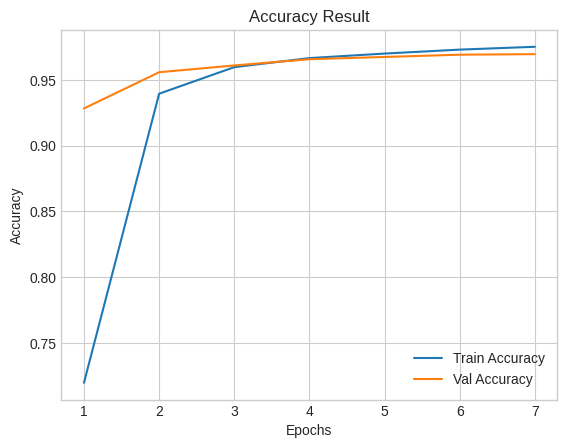

In [13]:
plot.Relplot

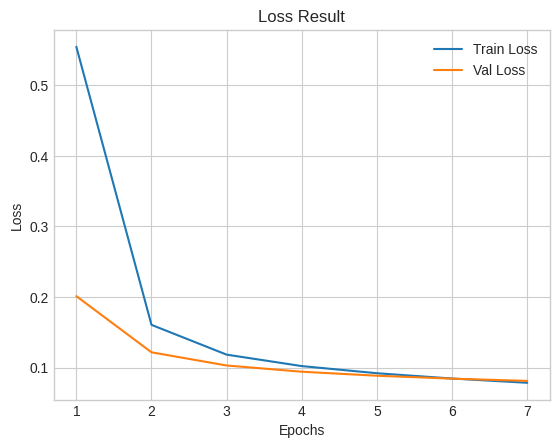

In [14]:
plot.Falplot